Who started BP mets and which agents were they on? Any stats significant differences here and illustrate

My interpretation: Is NHT agent choice independent of prior BP medication use?

OR: Is NHT agent choice independent of BP meds post?

In [99]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats

In [ ]:
BASE_FILE = os.path.join("..", "..", "data", "processed", "cardio_onc_prostate_06_broad_clean.csv")

df = pd.read_csv(BASE_FILE)

print(df.shape)
df.head()

mapping = {
    # Orgovyx
    'orgovyx': 'Orgovyx',
    'orogovyx': 'Orgovyx',
    'orgovyx and nubeqa': 'Orgovyx',


    # Lupron
    'lupron': 'Lupron',
    'lupron depot': 'Lupron',
    'leupron': 'Lupron',
    'lupon': 'Lupron',
    'lpron': 'Lupron',

    # Bicalutamide / Casodex
    'bicalutamide': 'Bicalutamide',
    'casodex': 'Bicalutamide',

    # Firmagon
    'firmagon': 'Firmagon',

    # Multi / transitions / combos
    'firmagon to lupron': 'Lupron',
    'lupron + casodex to lupron': 'Lupron',
    'lupron, orgovyx (d/c)': 'Lupron',
    'firmagon to orgovyx': 'Orgovyx',
    'lupron, firmagon': 'Lupron',
    'bicalutamide + lupron': 'Lupron',
    'bicalutamide, then lupron': 'Lupron',
    'casodex to lpron': 'Lupron',
    'bicalutamide to lupron to orgovyx': 'Orgovyx',
    'lupron + bicalutamide': 'Lupron',
    'lupron to orgovyx': 'Orgovyx',
    'bicalutamide to lupron': 'Lupron',
    'casodex to lupron': 'Lupron',
    'casodex to firmagon': 'Firmagon'
}

# Apply mapping
df["adt_agent"] = df["adt_agent"].replace(mapping)

(239, 60)


In [101]:
# document missingness
print(df["bp_meds_prior"].value_counts(dropna=False))
print(df["bp_meds_post"].value_counts(dropna=False))


na_count = df["bp_meds_prior"].isna().sum()
na_pct = na_count / len(df) * 100

print(f"Missing bp_meds_prior: {na_count} ({na_pct:.1f}%) out of {len(df)} patients")

bp_meds_prior
0.0    82
1.0    70
2.0    47
NaN    36
3.0     4
Name: count, dtype: int64
bp_meds_post
0.0    165
NaN     37
1.0     25
2.0     11
3.0      1
Name: count, dtype: int64
Missing bp_meds_prior: 36 (15.1%) out of 239 patients


In [102]:
df["bp_meds_prior"] = df["bp_meds_prior"].where(
    df["bp_meds_prior"].isna(),
    (df["bp_meds_prior"] != 0).astype(int)
)

df["bp_meds_post"] = df["bp_meds_post"].where(
    df["bp_meds_post"].isna(),
    (df["bp_meds_post"] != 0).astype(int)
)

print(df["bp_meds_post"].value_counts(dropna=False))

print(df["bp_meds_prior"].value_counts(dropna=False))


bp_meds_post
0.0    165
NaN     37
1.0     37
Name: count, dtype: int64
bp_meds_prior
1.0    121
0.0     82
NaN     36
Name: count, dtype: int64


In [103]:
# prevalence

valid_htn = df["bp_meds_prior"].notna()

n_total = valid_htn.sum()
n_htn = df.loc[valid_htn, "bp_meds_prior"].sum()
pct_htn = n_htn / n_total * 100

print(f"Overall bp_meds_prior prevalence: {n_htn}/{n_total} ({pct_htn:.1f}%) [excluding missing]")

Overall bp_meds_prior prevalence: 121.0/203 (59.6%) [excluding missing]


In [104]:
from scipy.stats import chi2_contingency

# contingency table
table = pd.crosstab(df["bp_meds_prior"], df["specific_nht_used"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)
print("df:", dof)

print("\nExpected counts:")
print(pd.DataFrame(expected, index=table.index, columns=table.columns))

Chi-square: 0.7913934789082246
p-value: 0.8515244730385072
df: 3

Expected counts:
specific_nht_used  Abiraterone  Apalutamide  Darolutamide  Enzalutamide
bp_meds_prior                                                          
0.0                  35.950739     5.251232     33.123153      7.674877
1.0                  53.049261     7.748768     48.876847     11.325123


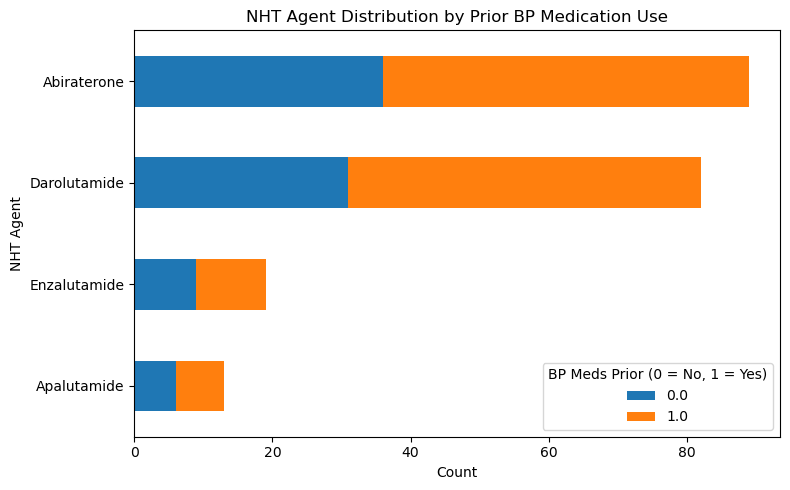

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

# counts table (no normalization)
ct = pd.crosstab(df["bp_meds_prior"], df["specific_nht_used"])

# transpose so NHT agents become rows
ct_t = ct.T

# reorder bars by total size (descending)
ct_t = ct_t.loc[ct_t.sum(axis=1).sort_values(ascending=True).index]

# plot
ax = ct_t.plot(kind="barh", stacked=True, figsize=(8,5))

# labels
ax.set_title("NHT Agent Distribution by Prior BP Medication Use")
ax.set_ylabel("NHT Agent")
ax.set_xlabel("Count")

plt.legend(title="BP Meds Prior (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

## BP Meds Post

Test whether post-treatment BP medication (bp_meds_post) differs by NHT agent

Test whether the effect of NHT agent on post-treatment BP medication use depends on prior BP medication status

In [106]:
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df["specific_nht_used"], df["bp_meds_post"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 1.8467642815366059
p-value: 0.6048117584383501


In [107]:
import statsmodels.formula.api as smf

model = smf.logit(
    "bp_meds_post ~ C(specific_nht_used)",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.471619
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           bp_meds_post   No. Observations:                  202
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            3
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                0.009544
Time:                        15:19:31   Log-Likelihood:                -95.267
converged:                       True   LL-Null:                       -96.185
Covariance Type:            nonrobust   LLR p-value:                    0.6071
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               -1.2384      0.2

In [108]:
import pandas as pd
import statsmodels.formula.api as smf

# keep only needed columns + drop missing
model_df = df[[
    "bp_meds_post",
    "bp_meds_prior",
    "specific_nht_used"
]].dropna()

# make sure outcome is 0/1
model_df["bp_meds_post"] = model_df["bp_meds_post"].astype(int)
model_df["bp_meds_prior"] = model_df["bp_meds_prior"].astype(int)

# fit interaction model
model = smf.logit(
    "bp_meds_post ~ C(specific_nht_used) * bp_meds_prior",
    data=model_df
).fit()

print(model.summary())

         Current function value: 0.442028
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:           bp_meds_post   No. Observations:                  202
Model:                          Logit   Df Residuals:                      194
Method:                           MLE   Df Model:                            7
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                 0.07169
Time:                        15:19:31   Log-Likelihood:                -89.290
converged:                      False   LL-Null:                       -96.185
Covariance Type:            nonrobust   LLR p-value:                   0.05502
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                                             -2.0794   

c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


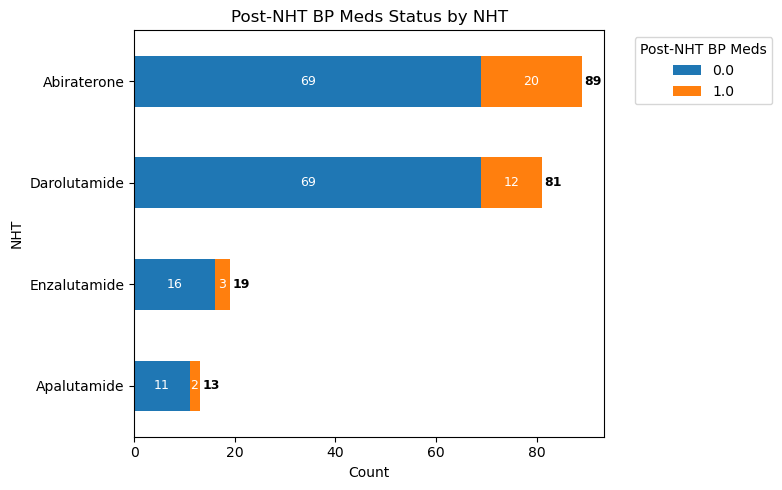

In [115]:
# contingency table (counts)
ct = pd.crosstab(df["specific_nht_used"], df["bp_meds_post"])

# reorder rows by TOTAL bar size (ascending)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]

# plot
ax = ct.plot(kind="barh", stacked=True, figsize=(8,5))

# add segment labels
for i, (index, row) in enumerate(ct.iterrows()):
    left = 0
    for col in ct.columns:
        value = row[col]
        if value > 0:
            ax.text(left + value/2, i, str(value),
                    ha='center', va='center', fontsize=9, color='white')
        left += value

# (optional) add total at end of each bar
totals = ct.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(total + 0.5, i, str(total),
            va='center', fontsize=9, fontweight='bold')

# labels
ax.set_title("Post-NHT BP Meds Status by NHT")
ax.set_ylabel("NHT")
ax.set_xlabel("Count")

plt.legend(title="Post-NHT BP Meds", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

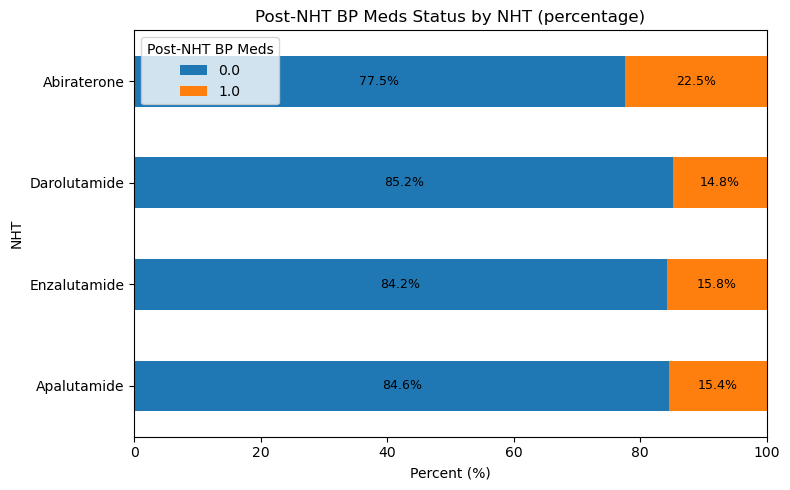

In [116]:
import pandas as pd
import matplotlib.pyplot as plt

# contingency table (counts)
ct = pd.crosstab(df["specific_nht_used"], df["bp_meds_post"])

# reorder by total bar size (descending)
ct["Total"] = ct.sum(axis=1)
ct = ct.sort_values("Total", ascending=True).drop(columns="Total")

# convert to row-wise percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# plot horizontal stacked percentage bar chart
ax = ct_pct.plot(kind="barh", stacked=True, figsize=(8,5))

# labels
ax.set_title("Post-NHT BP Meds Status by NHT (percentage)")
ax.set_xlabel("Percent (%)")
ax.set_ylabel("NHT")

plt.legend(title="Post-NHT BP Meds")

# annotate percentages
for i, idx in enumerate(ct_pct.index):
    left = 0
    for col in ct_pct.columns:
        val = ct_pct.loc[idx, col]
        ax.text(left + val/2, i, f"{val:.1f}%", va="center", ha="center", fontsize=9)
        left += val

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

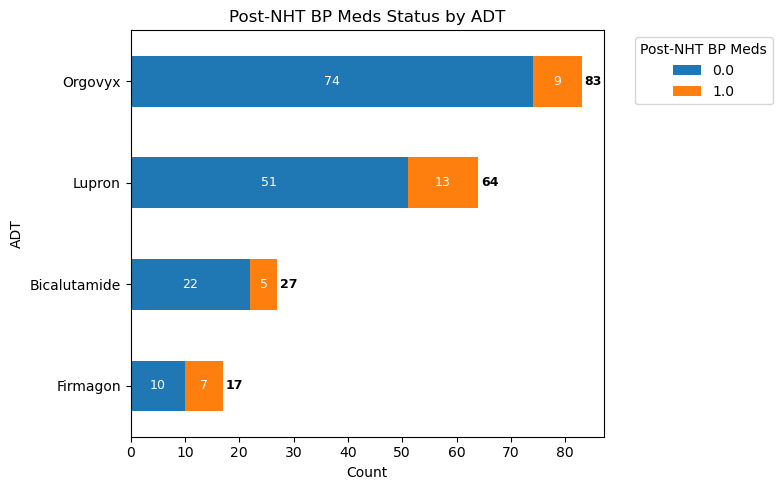

In [111]:
# contingency table (counts)
ct = pd.crosstab(df["adt_agent"], df["bp_meds_post"])

# reorder rows by TOTAL bar size (ascending)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]

# plot
ax = ct.plot(kind="barh", stacked=True, figsize=(8,5))

# add segment labels
for i, (index, row) in enumerate(ct.iterrows()):
    left = 0
    for col in ct.columns:
        value = row[col]
        if value > 0:
            ax.text(left + value/2, i, str(value),
                    ha='center', va='center', fontsize=9, color='white')
        left += value

# (optional) add total at end of each bar
totals = ct.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(total + 0.5, i, str(total),
            va='center', fontsize=9, fontweight='bold')

# labels
ax.set_title("Post-NHT BP Meds Status by ADT")
ax.set_ylabel("ADT")
ax.set_xlabel("Count")

plt.legend(title="Post-NHT BP Meds", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

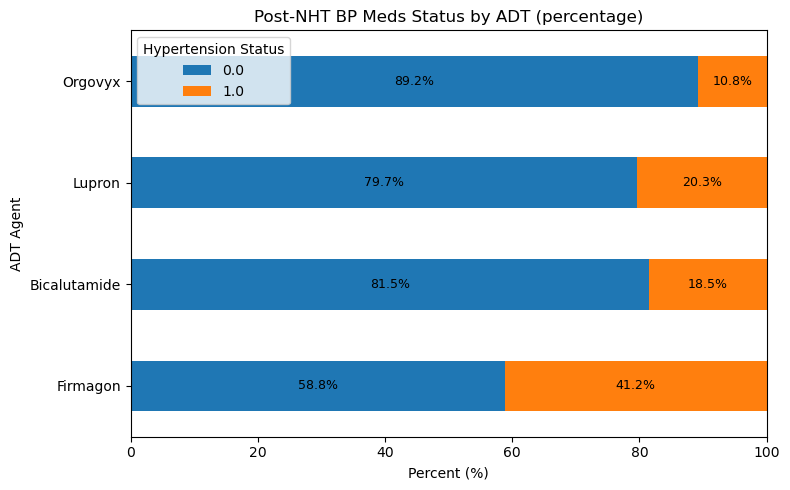

In [113]:
import pandas as pd
import matplotlib.pyplot as plt

# contingency table (counts)
ct = pd.crosstab(df["adt_agent"], df["bp_meds_post"])

# reorder by total bar size (descending)
ct["Total"] = ct.sum(axis=1)
ct = ct.sort_values("Total", ascending=True).drop(columns="Total")

# convert to row-wise percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# plot horizontal stacked percentage bar chart
ax = ct_pct.plot(kind="barh", stacked=True, figsize=(8,5))

# labels
ax.set_title("Post-NHT BP Meds Status by ADT (percentage)")
ax.set_xlabel("Percent (%)")
ax.set_ylabel("ADT Agent")

plt.legend(title="Hypertension Status")

# annotate percentages
for i, idx in enumerate(ct_pct.index):
    left = 0
    for col in ct_pct.columns:
        val = ct_pct.loc[idx, col]
        ax.text(left + val/2, i, f"{val:.1f}%", va="center", ha="center", fontsize=9)
        left += val

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [119]:
import statsmodels.formula.api as smf

model = smf.logit(
    "bp_meds_post ~  C(adt_agent) + C(specific_nht_used)",
    data=df
).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.439119
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           bp_meds_post   No. Observations:                  191
Model:                          Logit   Df Residuals:                      184
Method:                           MLE   Df Model:                            6
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                 0.06244
Time:                        15:41:10   Log-Likelihood:                -83.872
converged:                       True   LL-Null:                       -89.457
Covariance Type:            nonrobust   LLR p-value:                   0.08322
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               -1.1865      0.5

In [120]:
from scipy.stats import chi2_contingency

# contingency table
table_adt = pd.crosstab(df["bp_meds_post"], df["adt_agent"])

chi2, p, dof, expected = chi2_contingency(table_adt)

print("=== Chi-square test: bp_meds_post vs ADT agent ===")
print(f"Chi2 statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.6f}")

=== Chi-square test: bp_meds_post vs ADT agent ===
Chi2 statistic: 9.3796
Degrees of freedom: 3
P-value: 0.024647


In [122]:
from scipy.stats import chi2_contingency

# contingency table
table_adt = pd.crosstab(df["bp_meds_post"], df["specific_nht_used"])

chi2, p, dof, expected = chi2_contingency(table_adt)

print("=== Chi-square test: bp_meds_post vs NHT ===")
print(f"Chi2 statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.6f}")

=== Chi-square test: bp_meds_post vs NHT ===
Chi2 statistic: 1.8468
Degrees of freedom: 3
P-value: 0.604812


In [123]:
# explore significance between ADT and bp_meds_post

pd.crosstab(
    df["adt_agent"],
    df["bp_meds_post"],
    normalize="index"
)

bp_meds_post,0.0,1.0
adt_agent,,
Bicalutamide,0.814815,0.185185
Firmagon,0.588235,0.411765
Lupron,0.796875,0.203125
Orgovyx,0.891566,0.108434


In [124]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

table = pd.crosstab(df["adt_agent"], df["bp_meds_post"])

chi2, p, dof, expected = chi2_contingency(table)

residuals = (table - expected) / np.sqrt(expected)

residuals

bp_meds_post,0.0,1.0
adt_agent,,
Bicalutamide,-0.041120,0.088362
Firmagon,-1.063043,2.284342
Lupron,-0.221606,0.476203
Orgovyx,0.699149,-1.502382


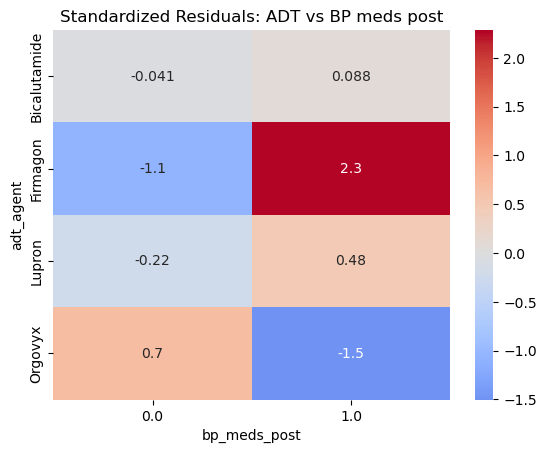

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(residuals, annot=True, cmap="coolwarm", center=0)
plt.title("Standardized Residuals: ADT vs BP meds post")
plt.show()

In [126]:
import numpy as np

n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.22160313282635924


In [127]:
import statsmodels.formula.api as smf

model = smf.logit(
    "bp_meds_post ~ C(adt_agent)",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.446303
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           bp_meds_post   No. Observations:                  191
Model:                          Logit   Df Residuals:                      187
Method:                           MLE   Df Model:                            3
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                 0.04710
Time:                        15:50:13   Log-Likelihood:                -85.244
converged:                       True   LL-Null:                       -89.457
Covariance Type:            nonrobust   LLR p-value:                   0.03796
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -1.4816      0.495     -2.991      0.003      -2.453

In [128]:
np.exp(model.params)

Intercept                   0.227273
C(adt_agent)[T.Firmagon]    3.080000
C(adt_agent)[T.Lupron]      1.121569
C(adt_agent)[T.Orgovyx]     0.535135
dtype: float64